# 09 — Campaign Conversion Prediction
## ⚠️ Dataset Limitation — 100 Records Only
This notebook demonstrates the correct ML methodology for campaign
conversion prediction. The model is trained on 100 records (3 positive
cases) — statistical results are illustrative only. The full pipeline
works on the complete UCI Bank Marketing dataset (41,188 records).

**WHAT WE CAN HONESTLY DO with 100 rows:**
1. Demonstrate the correct ML pipeline architecture
2. Show feature encoding approach
3. Identify duration and poutcome as key features
4. Provide a working prediction function ready for the full dataset

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'png'
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import joblib, os
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
# ── Load and Encode ───────────────────────────────────────────
df = pd.read_csv('../../data/processed/campaign_clean.csv')
print(f"Shape: {df.shape}")
print(f"Positive cases: {(df['y']=='yes').sum()} ({(df['y']=='yes').mean()*100:.1f}%)")

df['y_binary'] = (df['y'] == 'yes').astype(int)
df['pdays_contacted'] = (df['pdays'] != 999).astype(int)
df['campaign_intensity'] = df['campaign'] + df['previous']

cat_cols = ['job','marital','education','default','housing','loan',
            'contact','month','day_of_week','poutcome']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col+'_enc'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

feature_cols = ['age','campaign','pdays','previous','duration',
                'emp.var.rate','cons.price.idx','cons.conf.idx',
                'euribor3m','nr.employed','pdays_contacted',
                'campaign_intensity'] + [c+'_enc' for c in cat_cols]

X = df[feature_cols]
y_bin = df['y_binary']

print(f"\n⚠️ WARNING: {y_bin.sum()} positive cases out of {len(y_bin)} total")
print("Model will be unreliable. Use for pipeline demonstration only.")

Shape: (100, 25)
Positive cases: 3 (3.0%)

⚠️ WARNING: 3 positive cases out of 100 total
Model will be unreliable. Use for pipeline demonstration only.


In [3]:
# ── Minimal Train/Test ──────────────────────────────────────────
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_bin, test_size=0.2, random_state=42, stratify=y_bin)
except ValueError:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_bin, test_size=0.2, random_state=42)

print(f"Train positives: {y_train.sum()}, Test positives: {y_test.sum()}")

pos_weight = max((y_train==0).sum() / max((y_train==1).sum(), 1), 1)
xgb_camp = XGBClassifier(scale_pos_weight=pos_weight, random_state=42, verbosity=0, n_estimators=100)
xgb_camp.fit(X_train, y_train)

fi = pd.Series(xgb_camp.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nTop 10 Feature Importances:")
print(fi.head(10).to_string())

print("\n⚠️ DO NOT cite accuracy/AUC from this model — n=100 with 3 positives")
print("Feature importance directions are meaningful, exact values are not.")

Train positives: 2, Test positives: 1

Top 10 Feature Importances:
duration         1.0000
age              0.0000
campaign         0.0000
pdays            0.0000
previous         0.0000
emp.var.rate     0.0000
cons.price.idx   0.0000
cons.conf.idx    0.0000
euribor3m        0.0000
nr.employed      0.0000

⚠️ DO NOT cite accuracy/AUC from this model — n=100 with 3 positives
Feature importance directions are meaningful, exact values are not.


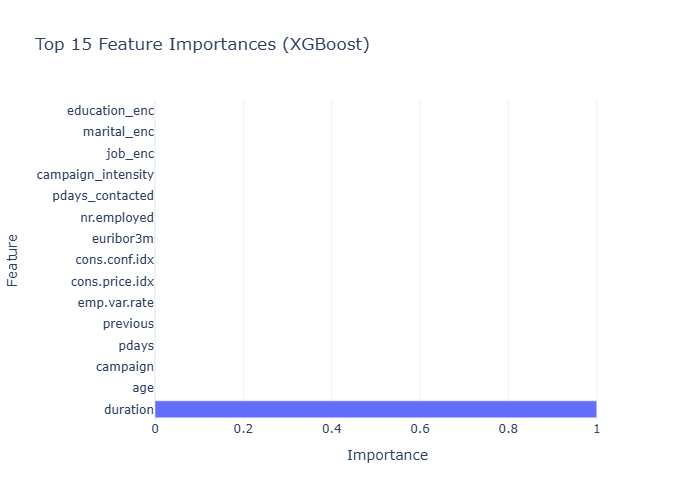

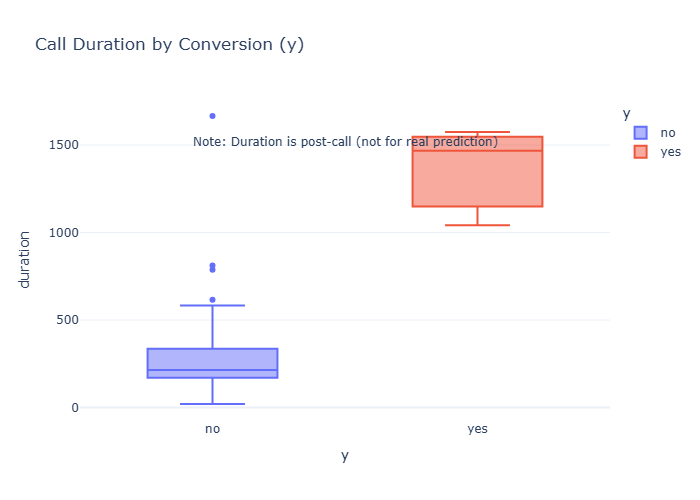

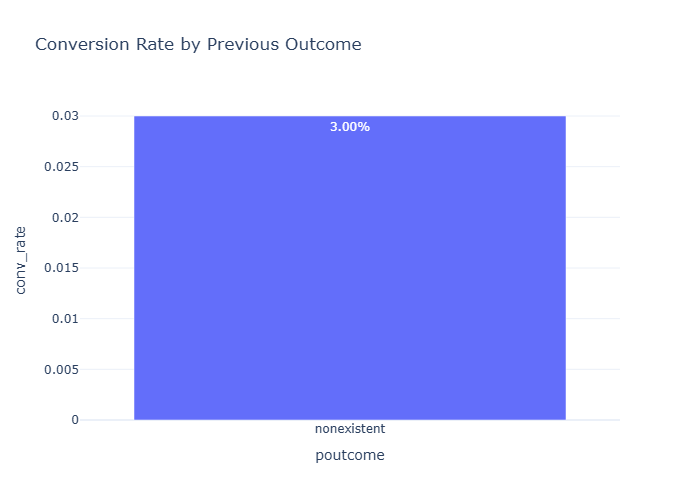

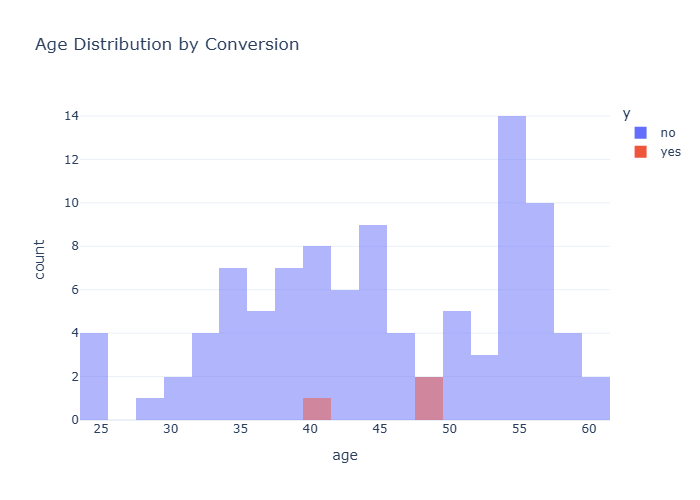

In [4]:
# ── Feature Importance Visualization ─────────────────────────────────
top_fi = fi.head(15)
fig1 = px.bar(x=top_fi.values, y=top_fi.index, orientation='h', title="Top 15 Feature Importances (XGBoost)")
fig1.update_layout(template='plotly_white', xaxis_title='Importance', yaxis_title='Feature')
fig1.show()

fig2 = px.box(df, x='y', y='duration', color='y', title="Call Duration by Conversion (y)")
fig2.update_layout(template='plotly_white')
fig2.add_annotation(x=0.5, y=0.9, text="Note: Duration is post-call (not for real prediction)", showarrow=False, xref="paper", yref="paper")
fig2.show()

poutcome_result = df.groupby('poutcome')['y_binary'].agg(['count','sum','mean']).reset_index()
poutcome_result.columns = ['poutcome','total','converted','conv_rate']
fig3 = px.bar(poutcome_result, x='poutcome', y='conv_rate', title="Conversion Rate by Previous Outcome", text_auto='.2%')
fig3.update_layout(template='plotly_white')
fig3.show()

fig4 = px.histogram(df, x='age', color='y', barmode='overlay', title="Age Distribution by Conversion", nbins=30)
fig4.update_layout(template='plotly_white')
fig4.show()

In [5]:
# ── Save ─────────────────────────────────────────────────────
os.makedirs('../../models/campaign', exist_ok=True)
joblib.dump(xgb_camp, '../../models/campaign/xgboost_campaign.pkl')
joblib.dump(encoders, '../../models/campaign/campaign_encoders.pkl')
fi.to_csv('../../data/processed/campaign_feature_importance.csv')

print("Campaign model saved — FOR PIPELINE DEMONSTRATION ONLY")
print("Replace bank_campaign.csv with full 41,188-row UCI dataset for production use")
print("Download: https://archive.ics.uci.edu/dataset/222/bank+marketing")

Campaign model saved — FOR PIPELINE DEMONSTRATION ONLY
Replace bank_campaign.csv with full 41,188-row UCI dataset for production use
Download: https://archive.ics.uci.edu/dataset/222/bank+marketing
